# 📚 Indice

1. [Download del Dataset](#Download-del-Dataset)  
   &nbsp;&nbsp;1.1 [Presentazione del dataset](#Presentazione-del-dataset)  

2. [Operazioni Preliminari](#Operazioni-Preliminari)  
   &nbsp;&nbsp;2.1 [Valori Mancanti](#Valori-Mancanti)  

3. [Analisi generale dei dati](#Analisi-generale-dei-dati)  
   &nbsp;&nbsp;3.1 [Analisi univariata dei dati](#Analisi-univariata-dei-dati)  
   &nbsp;&nbsp;&nbsp;&nbsp;3.1.1 [Outliers](#outliers)  
   &nbsp;&nbsp;3.2 [Analisi Multivariata](#Analisi-Multivariata)  
   &nbsp;&nbsp;&nbsp;&nbsp;3.2.1 [Gravidanze rispetto il diabete](#Gravidanze-rispetto-il-diabete)  
   &nbsp;&nbsp;&nbsp;&nbsp;3.2.2 [Relazione tra Glucosio e BMI](#Relazione-tra-Glucosio-e-BMI)  
   &nbsp;&nbsp;&nbsp;&nbsp;3.2.3 [Gravidanze rispetto l’età](#Gravidanze-rispetto-letà)  
   &nbsp;&nbsp;&nbsp;&nbsp;3.2.4 [Glucosio e insulina](#Glucosio-e-insulina)  
   &nbsp;&nbsp;&nbsp;&nbsp;3.2.5 [Correlazione tra variabili](#Correlazione-tra-variabili)  

4. [Esercizi](#Esercizi)


# Download del Dataset

Il primo passo durante un analisi dei dati, è proprio quello di procurarsi i dati. Per fare ciò ci sono molte piattaforme a dsposizione, tra cui kaggle.com.

Uno dei problemi ricorrenti che si affronta nell'analisi dei dati è l'uso di dataset "spazzatura", dataset veramente veramente brutti che presentano diverse criticità, come valori mancanti, inconsistenti e non sempre veritieri. in questo notebook ci baseremo sul dataset "Pima Indians Diabetes Database".

L'obbiettivo sarà quello di estrarre più conoscenza possibile dai dati. 

Iniziamo caricando i dati

Questa sezione introduce un concetto fondamentale dell’analisi dei dati, mostrando in modo pratico come interpretare e visualizzare i risultati ottenuti tramite Python e librerie come pandas e matplotlib.

In [1]:
import pandas as pd
pima=pd.read_csv("./data//PIMA.xls")

Il primo passo è inanzitutto capire cosa rappresenta il dataset

In [2]:
pima.columns 

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [3]:
pima.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In questo caso, una delle cose fondamentali da fare è capire a fondo cosa rappresentano gli attributi presenti nel dataset, alcuni sono molto intuitivi tra cui:
- Glucose
- Blood pressure
- insulin
- Age 


Altri come :
- Skin Thickness
- BMI 
- DiabetesPedigreeFunction 
- Outcome


Risultano più difficili da comprendere in quanto non si è esperti di dominio. 

L'ideale in questi casi sarebbe avere a disposizione un esperto di dominio per farsi istruire su questi campi, o nel caso ottimo coloro che hanno acquisito e pulito i dati. Ma in questo scenario nulla di tutto ciò è presente, cosa è possibile fare? 

<details><summary>💡 Clicca per Scoprirlo</summary>Google è tuo amico, non dimenticarlo mai.</details>

## Presentazione del dataset

Questo dataset ha l'obiettivo di predire l'insorgenza del diabete (Tipo 2) in pazienti di sesso femminile, basandosi su 8 attributi diagnostici.
* **`Pregnancies`**: Numero di gravidanze avute.
* **`Glucose`**: Livello di glucosio nel plasma.
* **`BloodPressure`**: Pressione sanguigna diastolica (la "minima"), in mm Hg.
* **`SkinThickness`**: Spessore della plica cutanea del tricipite (in mm), un indicatore del grasso corporeo.
* **`Insulin`**: Livello di insulina nel siero (in ml).
* **`BMI`**: Indice di Massa Corporea (Body Mass Index), calcolato da peso e altezza.
* **`DiabetesPedigreeFunction`**: Un punteggio calcolato che stima il rischio genetico/familiare di diabete.
* **`Age`**: Età della paziente (in anni).

in fine
* **`Outcome`**: La variabile che idealmente dovremmo predire.
    * **0**: La paziente non ha il diabete.
    * **1**: La paziente ha il diabete.

# Operazioni Preliminari

Una volta studiato il dataset, e comprese le variabili con cui ci troviamo a lavorare è il momento di capire la mole di dati, se i dati sono puliti e in che modo possiamo agire su di essi.

In [4]:
len(pima) #lunghezza del dataset


768

In [5]:
pima.info() #descrizione di ogni colonna nel dataset, Attenzione se Dtype=Object significa che la colonna non contiene un solo tipo di dato (Es. numeri e stringhe mischiati)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Una situazione quasi ideale, non vi sono valori mancanti, ogni colonna ha un solo tipo di dato il che rende molto più facile lavorare con i dati.

Ma, questa cosa puzza, ad una prima occhiata non ci sono valori mancanti, ma se questi valori fossero stati sostituiti da qualcos'altro? (pratica comune) E' necessario un analisi più accurata...

In [24]:
pima.loc[299] #visualizziamo qualche esempio a campione in maniera tale da comprendere le tuple

Pregnancies                   8.00
Glucose                     112.00
BloodPressure                72.00
SkinThickness                 0.00
Insulin                       0.00
BMI                          23.60
DiabetesPedigreeFunction      0.84
Age                          58.00
Outcome                       0.00
Name: 299, dtype: float64

Visualizzando un po i dati randomicamente ci accorgiamo di una cosa molto sospetta... come si fa ad avere insulina e skin thickness a 0 ? dovresti essere morto da 20 anni.... 



## Valori Mancanti

Il formato dati risulta molto sospetto, in quanto non vi sono valori NaN, cosa bisogna fare in questo caso? 


E' necessario effettuare una ricerca di inconsistenze nel dataset, è possibile che lo 0 rappresenti i valori mancanti? 
Cerchiamo le persone a insulina 0...

In [7]:
ins=pima[pima["Insulin"]==0]#ottengo tutte le righe del dataset che hanno insulina 0
len(ins)

374

In [8]:
ins.head()#stampo le prime n righe del dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
7,10,115,0,0,0,35.3,0.134,29,0


OH NO! il 48% dei valori di unsulina risulta essere 0, quindi possiamo dedurre che siano mancanti. 
Ma forse è meglio fare un plot per capire la magnitudo del problema

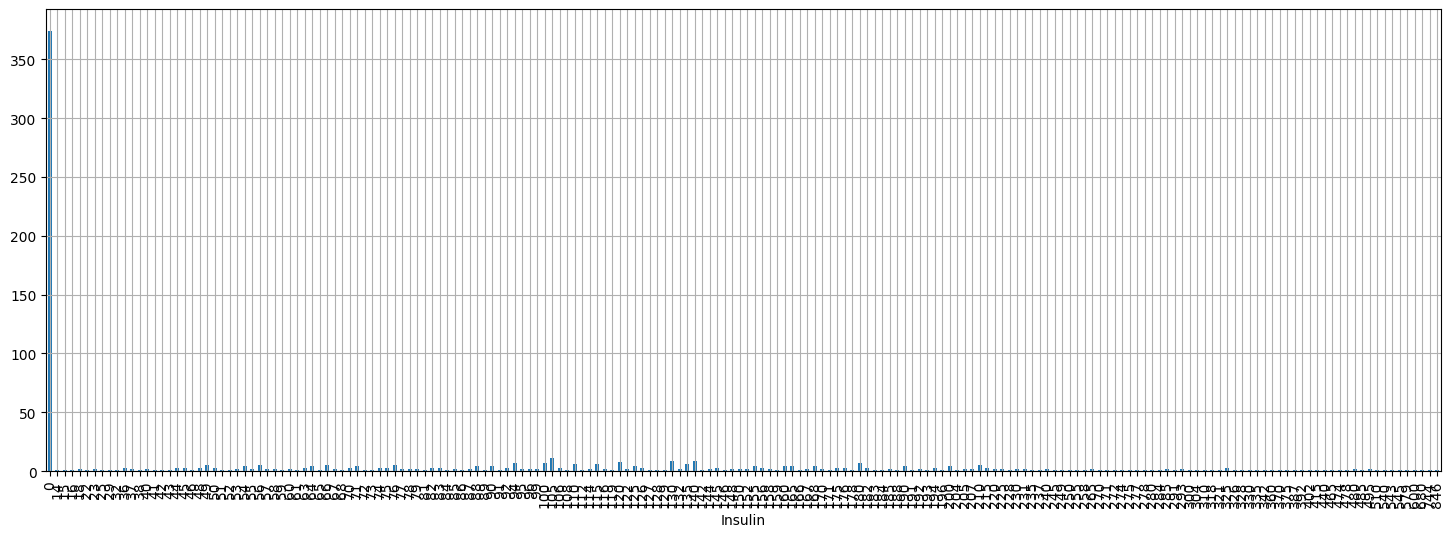

In [9]:
from matplotlib import pyplot as plt
pima['Insulin'].value_counts().sort_index().plot.bar(figsize=(18,6))
plt.grid()
plt.show()

Non riusciamo a visualizzare correttamente il plot poiché ci sono troppi valori di insulina. Cosa possiamo fare?
Usiamo la tecnica del binning, in questo caso faremo ricadere i valori di insulina in intervalli di 50 alla volta, creando una lista di bins

[-1, 0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900]


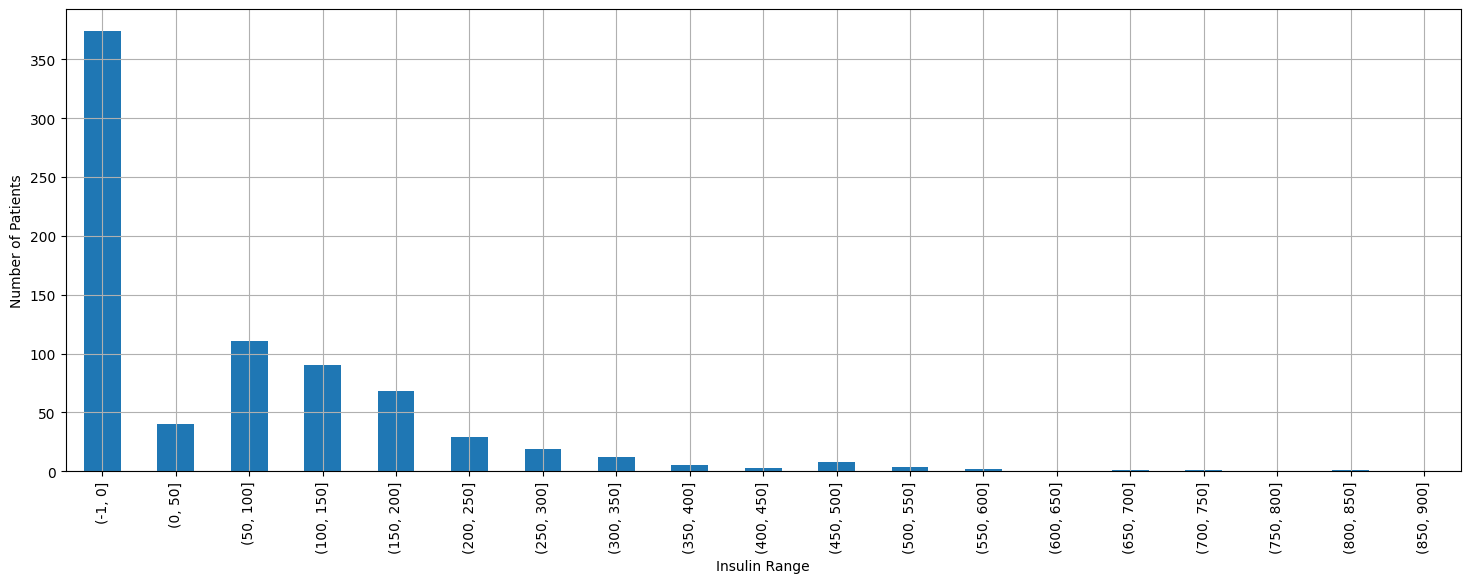

In [27]:

import pandas as pd
import numpy as np 


bins = [-1, 0] + list(range(50, 901, 50)) #facciamo una lista di bin
print(bins)

pd.cut(pima['Insulin'], bins=bins).value_counts().sort_index().plot.bar(figsize=(18,6)) #pd.cut binna gli elementi di una colonna in intervalli

plt.xlabel("Insulin Range") #etichetta asse x
plt.ylabel("Number of Patients") #etichetta asse y
plt.grid() #aggiunge griglia


plt.show()#mostra il grafico

Effettivamente la magnitudo delle persone ad insulina 0 risulta essere altissima, non consentendoci di visualizzare correttamente il dataset, e dandoci una visione distorta... meglio fare un altro plot dove escludiamo lo 0

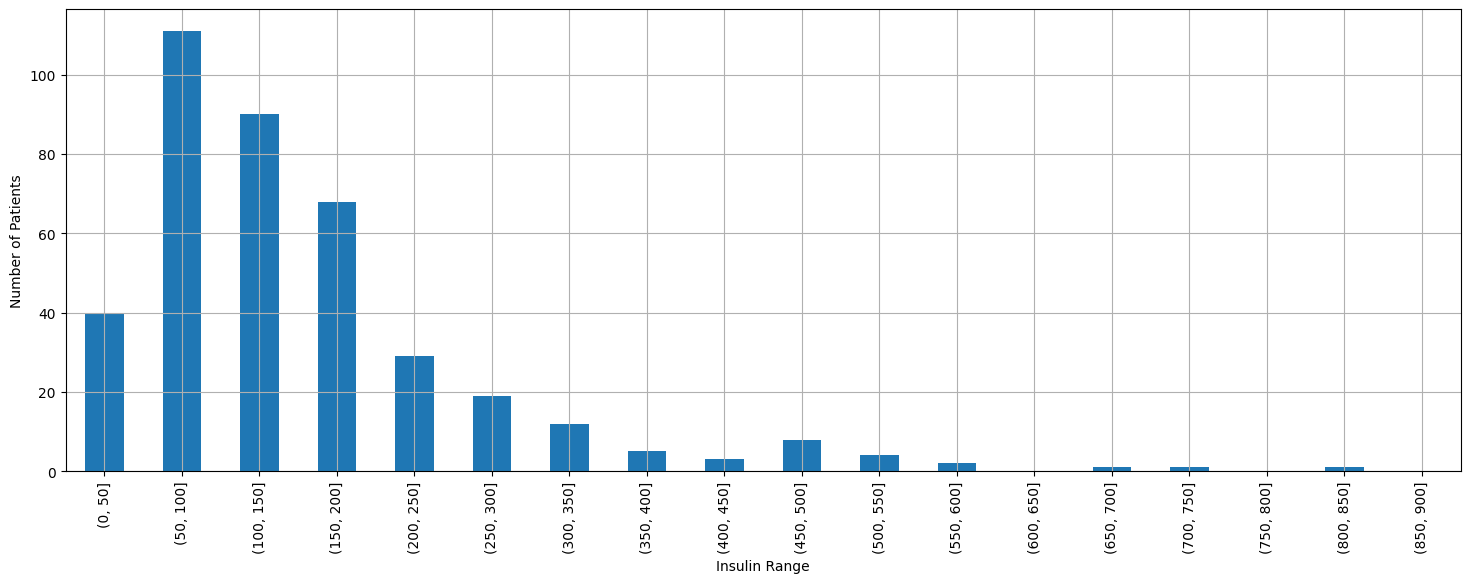

In [11]:

import pandas as pd
import numpy as np 


bins = [ 0] + list(range(50, 901, 50)) # escludendo il -1 il primo intervallo non conterrà i valori 0


pd.cut(pima['Insulin'], bins=bins).value_counts().sort_index().plot.bar(figsize=(18,6))

plt.xlabel("Insulin Range") #etichetta asse x
plt.ylabel("Number of Patients") #etichetta asse y

plt.grid()


plt.show()

Cosa possiamo dire? i dati sono inanzitutto ben visualizzabili, nel range 1/150 ad occhio notiamo la maggiorparte dei dati, vi sono anche diverse osservazioni per gli scaglioni successivi. Il dataset descrive quindi i diversi valori di insulina se si omettono gli zeri, ciò porta a pensare che malgrado il grande numero di valori a zero è possibile utilizzare comunque i valori di insulina presenti, senza dover per forza effettuare un drop delle righe nulle. 

Controlliamo adesso i valori mancanti per ogni variabile

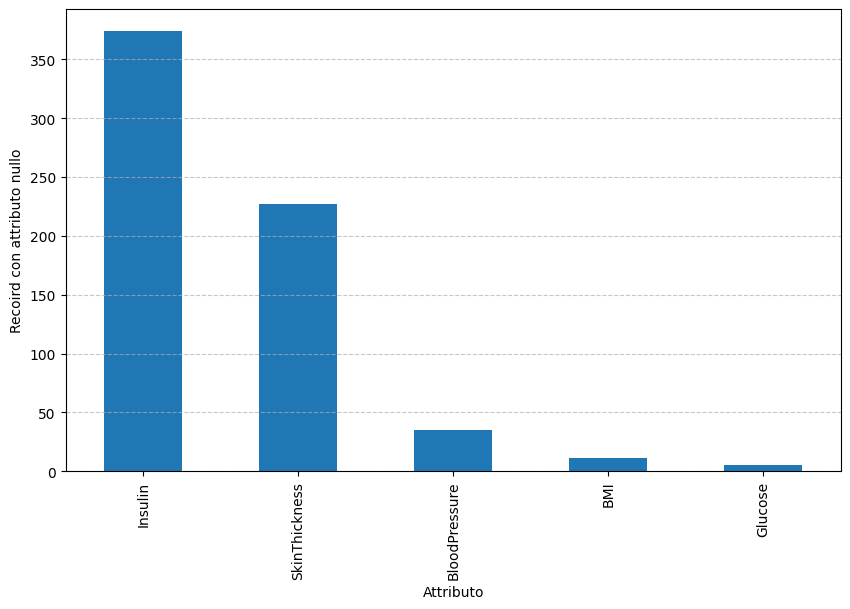

In [12]:

zero_counts = (pima.drop(["Outcome","Pregnancies"],axis=1) == 0).sum() #droppiamop le colonne Outcome e Pregnancies perchè queste ha senso che abbiano zeri


zero_counts_to_plot = zero_counts[zero_counts > 0]# Prendiamo le colonne che hanno almeno uno zero


zero_counts_to_plot.sort_values(ascending=False).plot.bar(figsize=(10, 6)) #sort dei risultati per rendere il grafico più leggibile


plt.grid(axis='y', linestyle='--', alpha=0.7) #Griglia prizzontale 

plt.xlabel("Attributo") 
plt.ylabel("Recoird con attributo nullo") 

plt.show()

Il numero di elementi a zero maggiore appartiene alla colonna Insulin, come possiamo notare vi è una grande quantità anche per SkinThinkness. il resto di colonne non sembra soffrire troppo del problema.

Arrivati in questo momento abbiamo molta più conoscenza del dataset, sappiamo cosa rappresenta ogni variabile, sappiamo quali sono i valori mancanti e qual è la convenzione utilizzata per rappresentarli.
Sappiamo che ogni colonna è ben formattata poichè non sono presenti problemi di tipo.
Tenedo a mente queste cose vogliamo esplorare i dati per capire intuitivamente se le variabili tra di loro hanno un qualche legame.

# Analisi generale dei dati

L'obbiettivo della sezione di analisi è quello di estrarre pattern dai dati acquisiti al fine di sfruttare questi ultimi. Bisogna tenere a mente che il dataset in questione è stato creato per predire quando un paziente ha o meno il diabete basandosi sugli 8 attributi acquisiti. 
L'analisi banale mette in relazione le 8 variabili acquisite con l'attributo outcome, analisi interessante ma che ogni singolo analista farebbe appena preso in mano il dataset. 

Un processo di analisi più interessante si basa inanzitutto sull'esplorazione singola delle variabili (Analisi univariata), al fine di comprenderne distribuzione e presenza di outlier, che consentono di giudicare la qualità di acquisizione del dataset, cosa che potrebbe portare ad acquisire nuovi dati in quanto quelli presenti potrebbero non essere sufficienti o escludere una fetta importante della popolazione. 
Un secondo step nell'analisi è quello di mettere in relazione più variabili tra di loro, comprendendo come una variabile aumenti o diminuisca di valore all'aumentare o diminuire di un altra variabile (Analisi multivariata). Questa analisi non deve riguardare in maniera obbligatoria la variabile che vogliamo predire (in questo caso outcome) ma può focalizzarsi anche su altre variabili, rendendo l'analisi veramente completa.

## Analisi univariata dei dati
Dopo aver trovato incosistenze nei dati è necessario analizzarli, alla ricerca di eventuali pattern. Effettueremo l'analisi su ogni singola variabile al fine di comprenderne la distribuzione con l'obbiettivo di trovare criticità presenti nelle variabili.

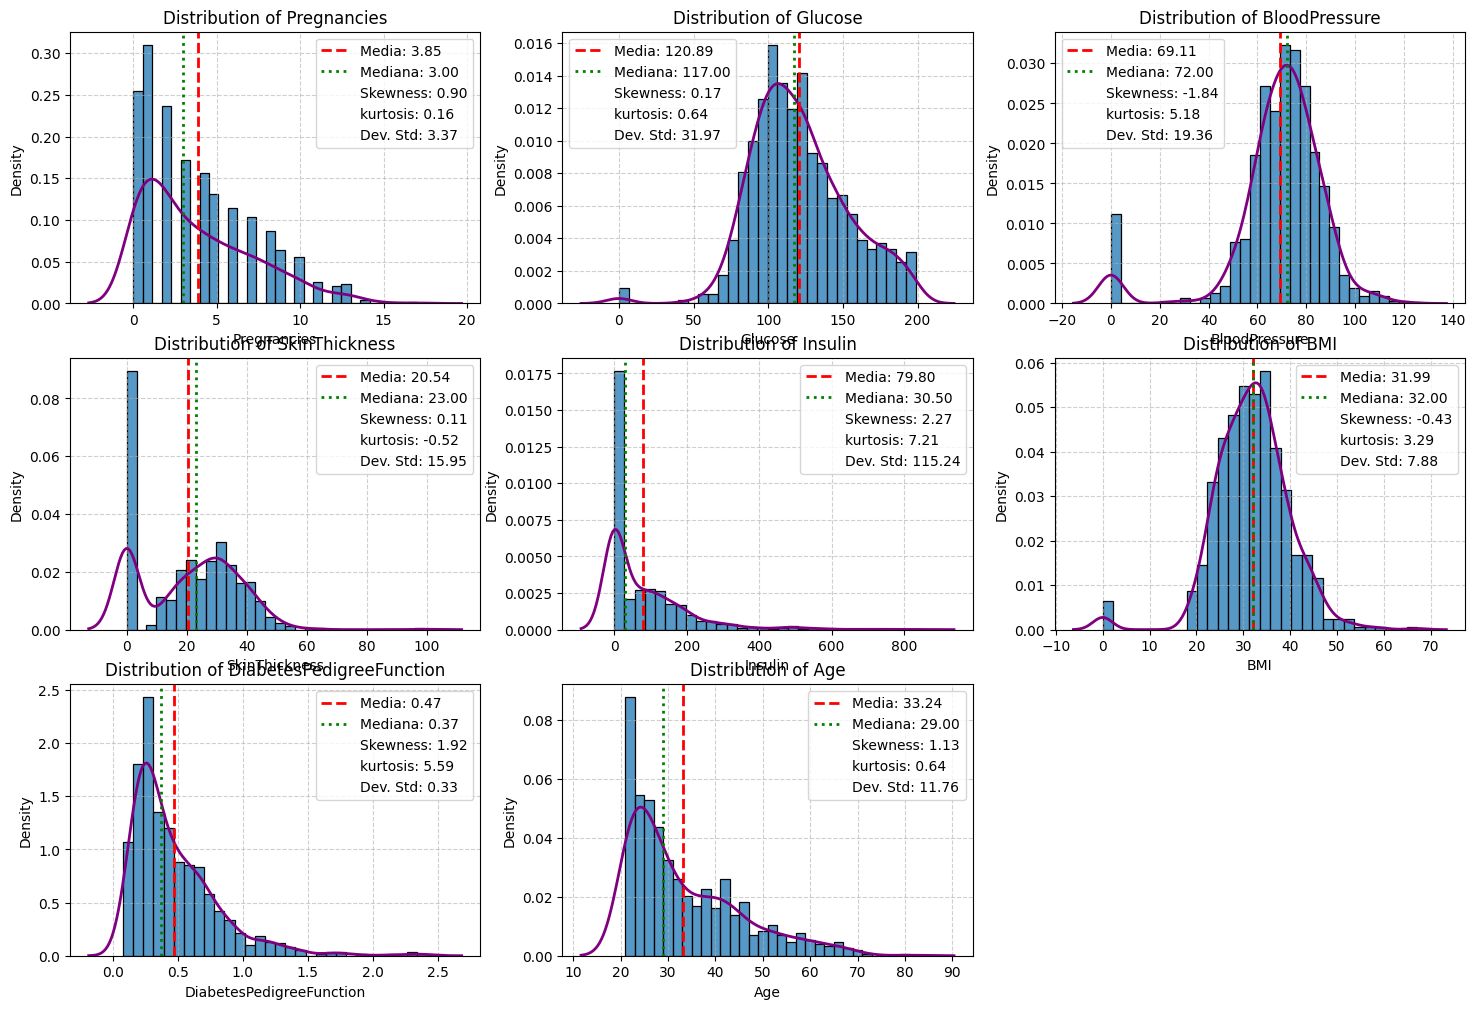

In [29]:


import seaborn as sns #usiamo sns che è più bello, consiglio di dare un occhiata alla libreria


plt.figure(figsize=(18,12)) #creiamo un plot di dimensione 18x15
for i, col in enumerate(pima.columns[:-1]): #tutte le colonne eccetto Outcome
    plt.subplot(3,3,i+1) #nel plot grande inseriamo dei subplot 3x3 a poszione i+1 (si inizia a contare da 1 qui)
    ax=sns.histplot(pima[col], bins=30, edgecolor = "black", stat='density') #istogramma
    sns.kdeplot(pima[col],  color='purple',lw=2, ax=ax) #densità sopra l'istogramma
    plt.title(f"Distribution of {col}") #titolo del subplot
    mean_val = pima[col].mean()
    median_val = pima[col].median()
    skew_val = pima[col].skew()  
    kurt_val = pima[col].kurt()
    std_val = pima[col].std()
    
    
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')#linea verticale per la media
    plt.axvline(median_val, color='green', linestyle=':', linewidth=2, label=f'Mediana: {median_val:.2f}')#linea verticale per la mediana
    

    plt.plot([], [], ' ', label=f'Skewness: {skew_val:.2f}')# plot vuoti per inserire le etichette nella legenda
    plt.plot([], [], ' ', label=f'kurtosis: {kurt_val:.2f}')
    plt.plot([], [], ' ', label=f'Dev. Std: {std_val:.2f}')
    
    
    plt.legend() #facciamo vedere la legenda
    plt.grid(True, linestyle="--", alpha=0.6)

Com'è possibile notare insuline, DiabetesPedigreeFunction e Bloodpressure hanno valori di skewness e kurtosis alti, di conseguenza sono probabilmente presenti outliers. Preoccupante anche il plot di skinTickness in quanto sono presenti molti valori nulli. 
I rimanenti attributi sembrano avere un comportamento accettabile.


### outliers
Diamo un occhiata più da vicino agli outliers presenti nelle variabili incriminate. Effettuaiamo il box plot per ogni variabile rimuovendo i valori a zero in quanto lo 0 in questo caso indica assenza di dato.

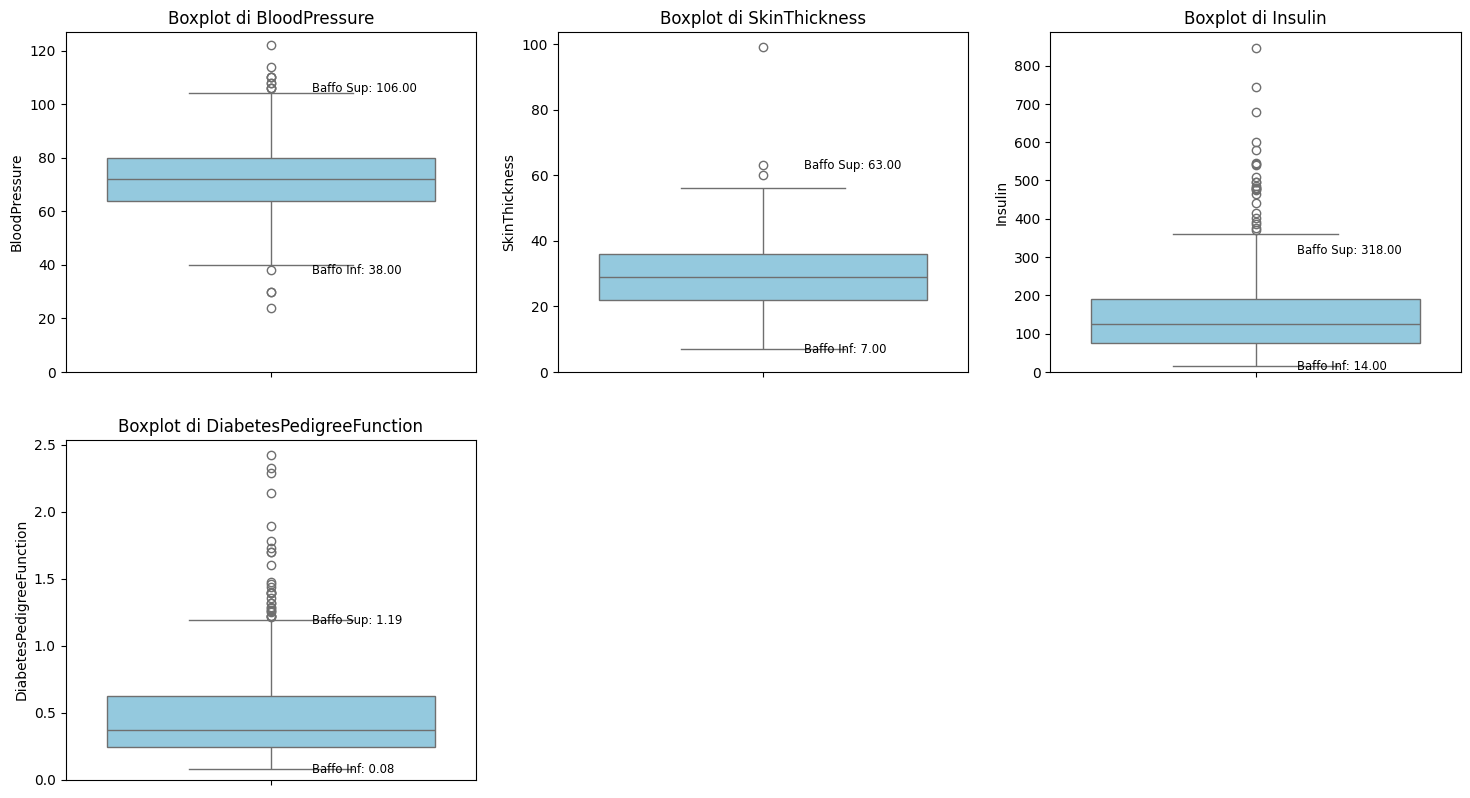

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




columns_to_analyze = [ 'BloodPressure', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction']

plt.figure(figsize=(18, 15))

for i in range(len(columns_to_analyze)):
    col = columns_to_analyze[i]
    
    # Crea il subplot
    ax = plt.subplot(3, 3, i + 1) #il plot è una variabile quindi volendo la possiamo salvare e passare alle funzioni di seaborn per appiccicarci i grafici sopra
    
    sns.boxplot(y=pima[pima[col]!=0][col], color='skyblue', whis=1.5,ax=ax) #leviamo gli zeri da queste colonne perchè sappiamo essere valori mancanti

    Q1 = pima[col].quantile(0.25)#calcoliamo i quartili per il boxplot
    Q3 = pima[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    

    whis_upper = pima[pima[col]!=0][col][pima[col] <= upper_bound].max()#baffo superiore
    whis_lower = pima[pima[col]!=0][col][pima[col] >= lower_bound].min()#baffo inferiore


    ax.text(0.1, whis_upper, f'Baffo Sup: {whis_upper:.2f}', 
            horizontalalignment='left', size='small', color='black', va='center') #appiccico il testo sul grafico
    ax.text(0.1, whis_lower, f'Baffo Inf: {whis_lower:.2f}', 
            horizontalalignment='left', size='small', color='black', va='center')
    
    plt.ylim(bottom=0) # vogliamo che sull'asse delle y ci sia sempre lo 0 all'inizio
    plt.title(f"Boxplot di {col}")


# Mostra il grafico
plt.show()


è possibile notare come valori di insulina superiori a 318 risultino essere outliers, cosa che aumenterà la difficoltà delle analisi successive e che potrebbe portare i modelli di predizione in errore. 

## Analisi Multivariata

Nella seguente sezione analizzeremo il comportamento di più variabili, effettuando un paragone tra di esse. 
Degli esempi di domande sull'analisi multivariata sono: 
- Come si distribuisce il numero di gravidanze per persone con e senza diabete?
- L'aumento del BMI porta ad avere valori di glucosio maggiori?
- Il numero di gravidanze cresce con l'età? è possibile che queste variabili siano ridondanti?
- La quantità di Glucosio nel sangue e la produzione di insulina come sono legati?

### Gravidanze rispetto il diabete

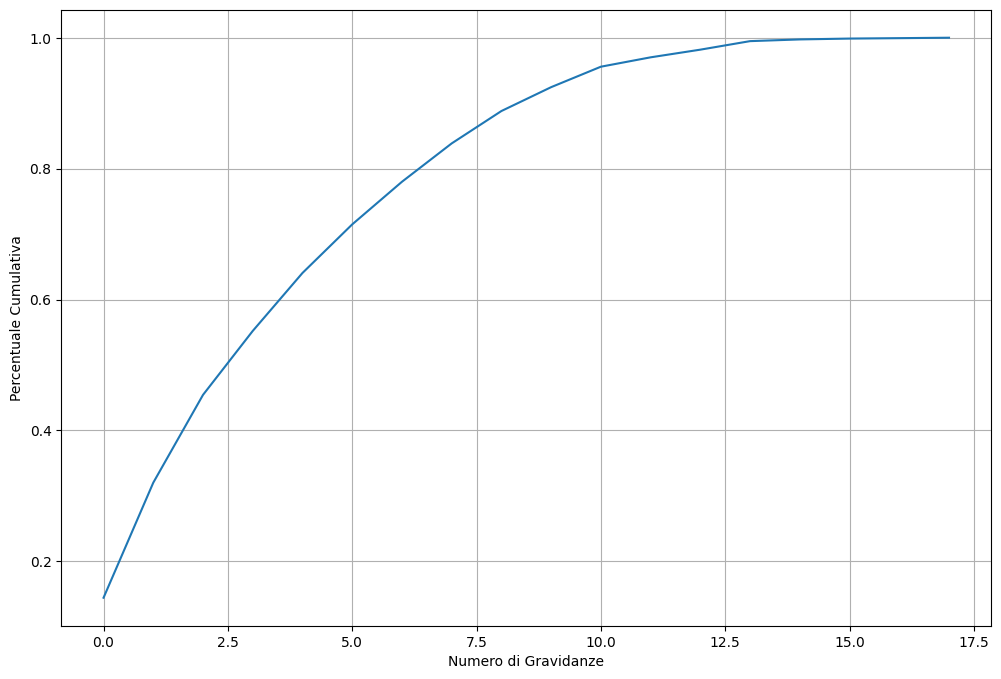

In [15]:
pima['Pregnancies'].value_counts(normalize=True).sort_index().cumsum().plot(figsize=(12,8)) #distibuzione cumulativa delle gravidanze
plt.xlabel("Numero di Gravidanze")
plt.ylabel("Percentuale Cumulativa")
plt.grid()

La CMF è bellissima ma così non ce ne facciamo niente. Per il nostro obbiettivo, vorremmo capire se persone affette da diabete e persone non affette hanno una CMF simile.

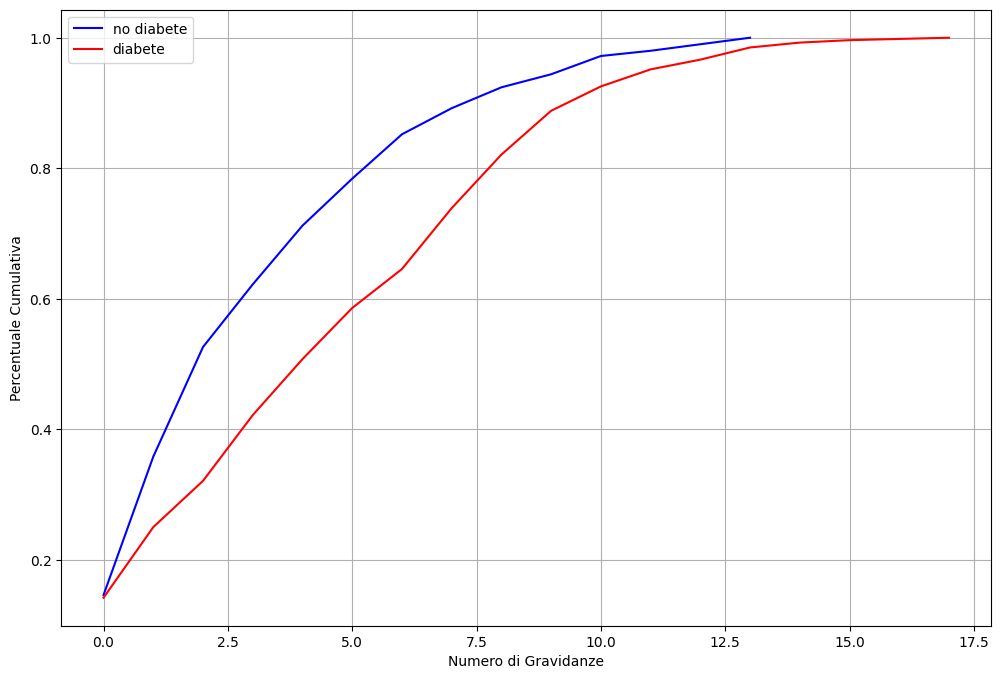

In [16]:

plt.figure(figsize=(12, 8))


pima[pima["Outcome"]==0]['Pregnancies'].value_counts(normalize=True).sort_index().cumsum().plot(label='no diabete', color='blue')


pima[pima["Outcome"]==1]['Pregnancies'].value_counts(normalize=True).sort_index().cumsum().plot(label='diabete', color='red')

plt.legend()
plt.grid()
plt.xlabel("Numero di Gravidanze")
plt.ylabel("Percentuale Cumulativa")
plt.show()

Interessante!!! la CMF relativa alle gravidanze sembrebbe tendere verso sinistra per persone non affette da diabete, il che potrebbe indicare che un numero di gravidanze superiore influisce sulla probabilità di contrarre il diabete.

Potrebbe essere interessante effettuare un barplot per ottenere informazioni ulteriori.

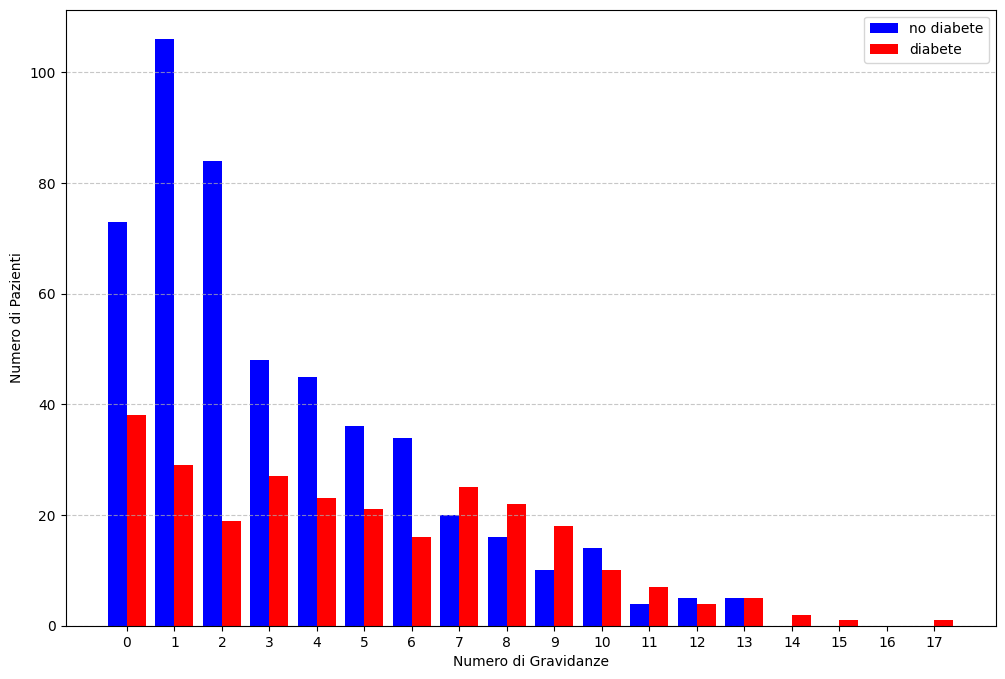

In [17]:

bins = np.arange(-0.5, pima['Pregnancies'].max() + 1.5, 1)


plt.figure(figsize=(12, 8))


plt.hist([pima[pima["Outcome"]==0]['Pregnancies'], pima[pima["Outcome"]==1]['Pregnancies']],
         bins=bins, 
         color=['blue', 'red'], 
         label=['no diabete', 'diabete'])


plt.xticks(range(int(pima['Pregnancies'].max()) + 1))


plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel("Numero di Gravidanze")
plt.ylabel("Numero di Pazienti")
plt.show()

Questo istogramma è molto confusionale, comè possibile notare moltissime persone con poche gravidenze non contraggono il diabete, mentre l'aumento delle gravidanze non sembra influire tantissimo sulla probabilità di contrarre il diabete poichè com'è possibile notare i bin sono molto vicini (Gravidanze maggiori di 6). A priva vista potrebbe sembrare più conveniente avere 10 gravidanze piuttosto che 9 !!! 
Questo lascia intuire che probabilmente il numero di gravidanze basso aiuta a non contrarre il diabete ma non è l'unico fattore discriminante, il che ci obbliga a analizzare gli altri.

### Relazione tra Glucosio e BMI

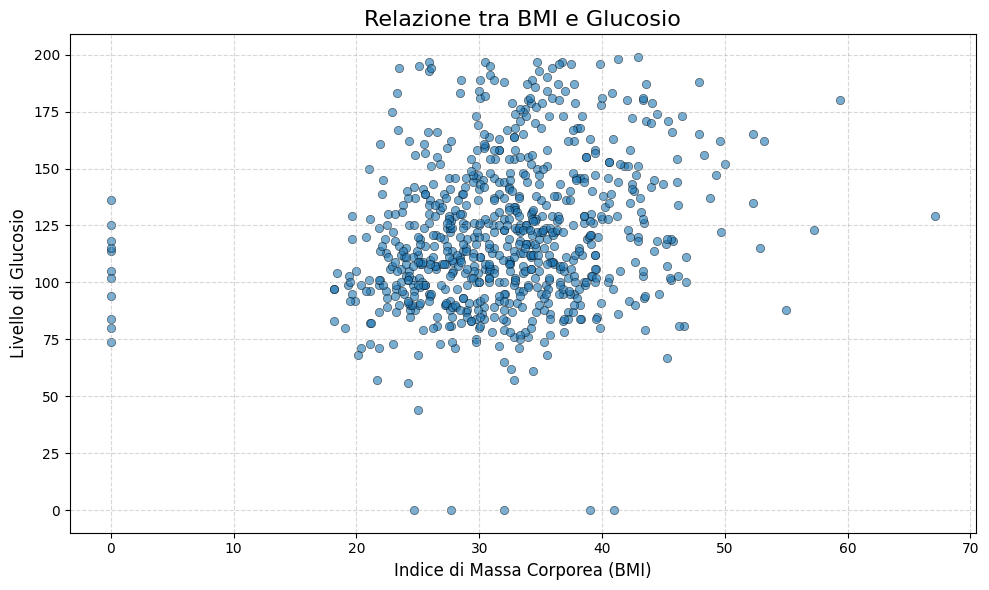

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(  #comando per fare uno scatter plot
    data=pima, #possiamo passare tutto il dataset
    x='BMI', #sull'asse delle x mettiamo questo attributo
    y='Glucose',
    alpha=0.6, # Aggiunge trasparenza per vedere i punti sovrapposti
    edgecolor='k' # Aggiunge un bordo ai punti
) 



plt.title('Relazione tra BMI e Glucosio', fontsize=16)
plt.xlabel('Indice di Massa Corporea (BMI)', fontsize=12)
plt.ylabel('Livello di Glucosio', fontsize=12)


plt.grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

Questo grafico mostra la relazione tra l'Indice di Massa Corporea (BMI) e il Livello di Glucosio.

Come si può osservare, l'indice di massa corporea non sembra influire moltissimo sul livello di glucosio nel sangue.

Ignorando i palesi dati anomali (come la colonna verticale a BMI 0), la stragrande maggioranza dei punti forma un "blob centrale" molto sparso. Questo indica che la correlazione tra le due variabili è debole: sebbene si possa notare che i livelli di glucosio tendono ad aumentare in minimissimo modo al crescere del BMI, i punti sono troppo dispersi per indicare una relazione. Sarebbe necessario acquisire ulteriori dati per confermare o smentire questa tesi.

### Gravidanze rispetto l'età 

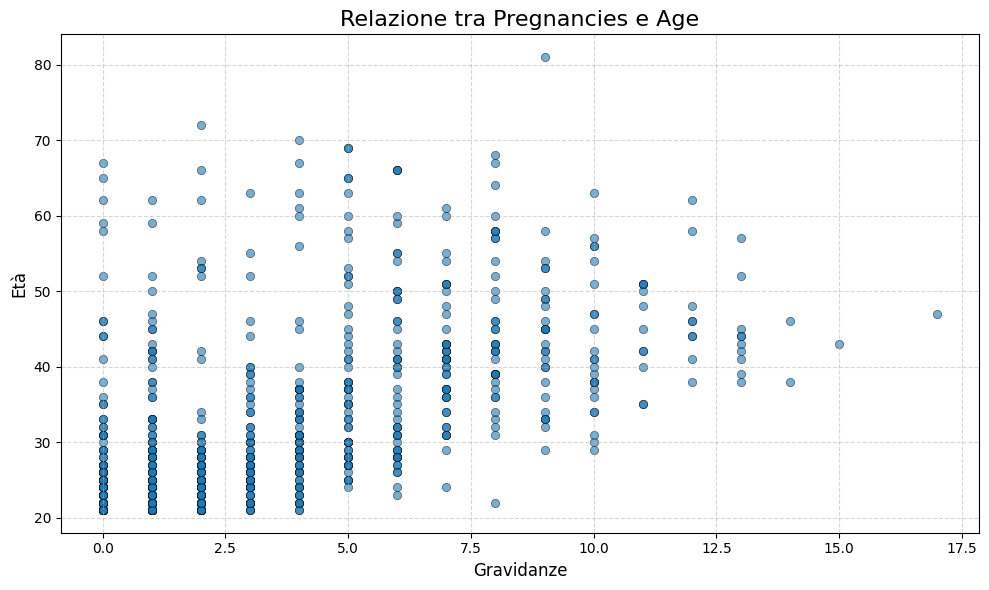

In [19]:
plt.figure(figsize=(10, 6))


sns.scatterplot(
    data=pima, 
    x='Pregnancies', 
    y='Age',
    alpha=0.6,
    edgecolor='k' 
)


plt.title('Relazione tra Pregnancies e Age', fontsize=16)
plt.xlabel('Gravidanze', fontsize=12)
plt.ylabel('Età', fontsize=12)


plt.grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

Le pazienti più giovani (es. 20-30 anni) si concentrano, come prevedibile, su un basso numero di gravidanze (principalmente tra 0 e 5).

Per avere un numero elevato di gravidanze (es. da 8 in su), l'età della paziente è necessariamente più alta (generalmente dai 30-40 anni in su) implicando una correlazione tra le variabili.

Per un basso numero di gravidanze (es. 0, 1, 2), l'età è molto variabile: ci sono sia pazienti giovani che pazienti anziane (fino a 70-80 anni) che hanno avuto poche o nessuna gravidanza.


### Glucosio e insulina

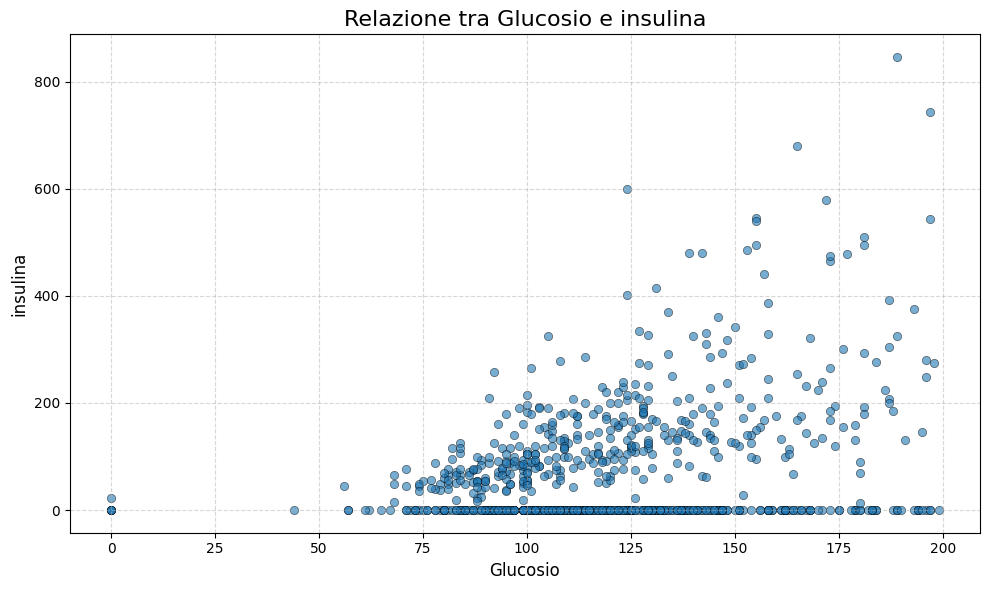

In [20]:
plt.figure(figsize=(10, 6))


sns.scatterplot(
    data=pima, 
    x='Glucose', 
    y='Insulin',
    alpha=0.6, 
    edgecolor='k'
)



plt.title('Relazione tra Glucosio e insulina', fontsize=16)
plt.xlabel('Glucosio', fontsize=12)
plt.ylabel('insulina', fontsize=12)


plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Se si ignorano i punti a 0, si osserva una chiara correlazione positiva. All'aumentare del livello di glucosio (asse X), tende ad aumentare anche il livello di insulina (asse Y). Questo è biologicamente corretto: il corpo rilascia più insulina per cercare di gestire un livello più alto di zucchero nel sangue. 
Insomma abbiamo scoperto l'acqua calda. 

Un analisi di questo tipo può sembrare "inutile" ma se i dati avessere raccontato una correlazione negativa o nessuna correlazione allora avremmo dovuto insospettirci, giudicandone la qualità.

### Correlazione tra variabili

Vediamo ora la matrice di correlazione. La correlazione tra variabili è un numero compreso tra -1 e 1 con i seguenti significati:

    Un numero negativo: all'aumentare della variabile X, la variabile Y tende a diminuire (relazione inversa).

    Un numero positivo: all'aumentare della variabile X, la variabile Y tende ad aumentare (relazione diretta).

    Un numero prossimo a 0: indica che X e Y non hanno una correlazione lineare. Questo significa che al crescere di X, la Y potrebbe aumentare, diminuire o rimanere stabile (non c'è un andamento lineare chiaro).

ATTENZIONE CORRELAZIONE NON INDICA UN RAPPORTO DI CAUSA EFFETTO, DESCRIVE SOLO COME CAMBIANO LE VARIABILI.

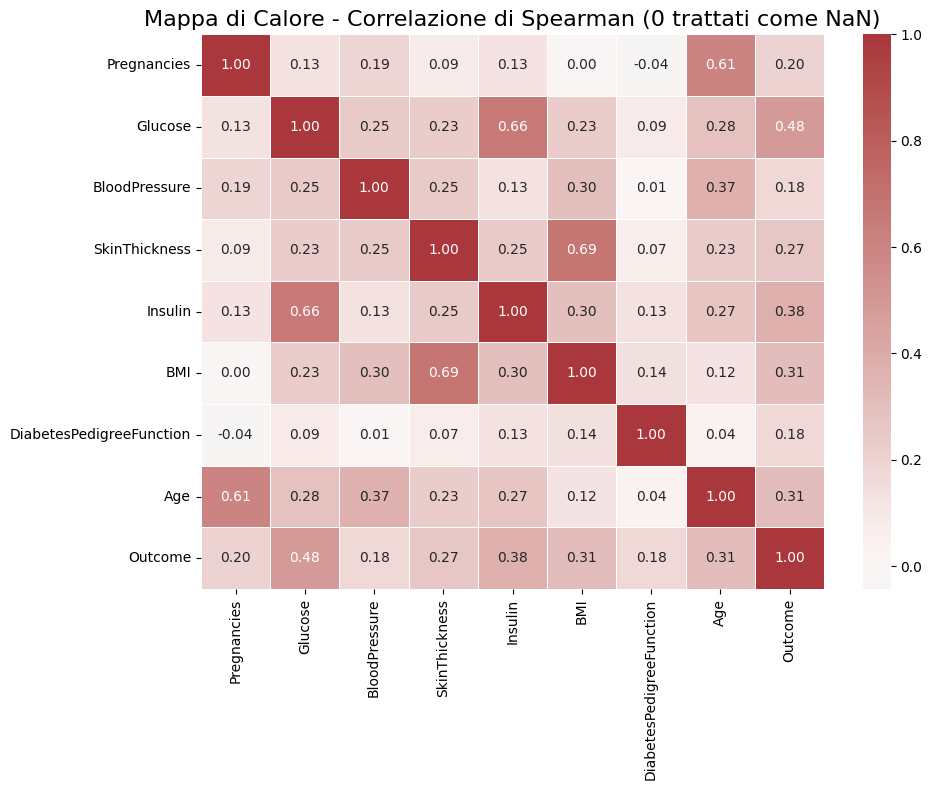

In [21]:
pima_cleaned = pima.copy()
    

cols_with_impossible_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

pima_cleaned[cols_with_impossible_zeros] = pima_cleaned[cols_with_impossible_zeros].replace(0, np.nan) #mettiamo i nan perchè quei valori 0 non hanno senso in queste colonne


correlation_matrix = pima_cleaned.corr(method='spearman') #calcoliamo una matrice di correlazione usando il metodo di spearman (vedrete meglio in teoria)

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True,        # Mostra i numeri dentro le celle
    fmt='.2f',         # Formatta i numeri a 2 decimali
    cmap='vlag',       # Colormap (Rosso=Positivo, Blu=Negativo)
    center=0,          # Il colore 0 è bianco
    linewidths=.5      # Linea di separazione tra le celle
)
plt.title("Mappa di Calore - Correlazione di Spearman (0 trattati come NaN)", fontsize=16)
plt.tight_layout()


plt.show()

# Esercizi
1. Carica un dataset diverso, ma comunque brutto (Consigliati:  "Used Cars Price Prediction"; "IMDb Movies extensive dataset"; "Annual Developer Survey" ).
2. Crea una relazione tecnica sugli attributi e la storia del dataset, perchè è stato acquisito e cosa rappresentano le variabili.
 Identifica anche usecase diversi del dataset. 
3. Trova la polvere sotto il tappeto, dati sporchi inconsistenti e mancanti, proponi qualcosa per risolvere i problemi strutturali.
4. Effettua analisi univariata e multivariata, trova relazioni o conferma l'assenza di esse, effettua ipotesi sul perché un fenomeno accade.
